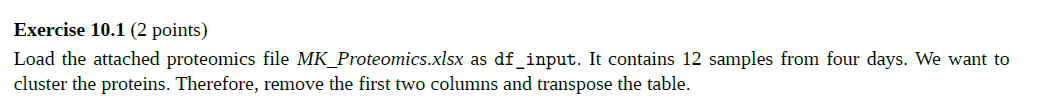

In [ ]:
import pandas as pd

#Load the Excel file
file_path = 'MK_Proteomics.xlsx'
df_input = pd.read_excel(file_path)

#Remove the first two columns
df_reduced = df_input.iloc[:, 2:]

#Transpose the table
df_transposed = df_reduced.transpose()

#Display the first few rows of the transposed dataframe to the user
print(df_transposed.head())


                  0             1              2             3             4   \
Q921I1  3.536346e+05  4.551555e+05  384493.584336    830.352438   8462.099886   
P01592  1.564424e+06  1.239219e+06  709675.511936   7442.646504  32160.450604   
Q62230  4.144102e+05  5.427394e+05  624395.234120  12618.038173  39861.268468   
P53657  2.388425e+05  2.414057e+05   70959.095520   2342.445879  11051.847961   
Q02650  6.483440e+05  2.142299e+05  225661.378550  11870.556906  24880.019573   

                   5             6             7             8             9   \
Q921I1   11256.728633    216.780323  12149.421496   7207.583849    391.210152   
P01592  100993.295750   7160.774894  13095.649556   3431.919506   7183.643299   
Q62230   16810.791128  40180.280078  35190.539219  56528.860688  74291.008997   
P53657    9740.634254   9108.514058   5658.092315  10185.293971  10757.833910   
Q02650    6621.764557  15833.581451   9465.086663  12277.251489   5402.831599   

                  10      

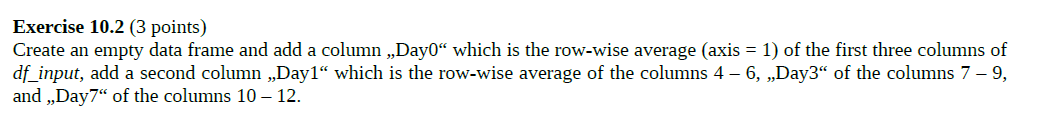

In [ ]:
import pandas as pd

# Assuming df_input is already loaded (e.g., from the previous step)
# and has the structure: [meta1, meta2, sample1, sample2, ..., sample12]

# 1. Create an empty DataFrame with the same index as df_input
df_summary = pd.DataFrame(index=df_transposed.index)

# 2. Compute the row‐wise means for each day’s set of three columns
#    Note: df_input.iloc[:, 2:5] corresponds to columns 3, 4, 5 (zero‐based indexing)
df_summary['Day0'] = df_transposed.iloc[:, 0:3].mean(axis=1)
df_summary['Day1'] = df_transposed.iloc[:, 3:6].mean(axis=1)
df_summary['Day3'] = df_transposed.iloc[:, 6:9].mean(axis=1)
df_summary['Day7'] = df_transposed.iloc[:, 9:12].mean(axis=1)

# 3. (Optional) Inspect the first few rows of the new DataFrame
print(df_summary.head())


                Day0          Day1          Day3          Day7
Q921I1  3.977612e+05   6849.726986   6524.595223   2719.056685
P01592  1.171106e+06  46865.464286   7896.114652   8518.453262
Q62230  5.271816e+05  23096.699256  43966.559995  90201.322969
P53657  1.837358e+05   7711.642698   8317.300115   8856.749974
Q02650  3.627451e+05  14457.447012  12525.306534  10673.744809


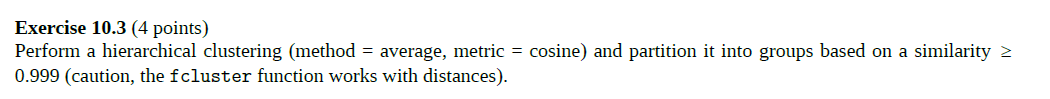

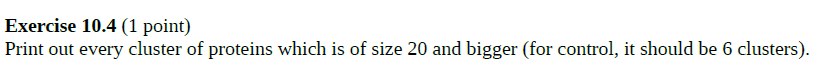

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform

lkg = hierarchy.linkage(df_summary, method = 'average', metric = "cosine")
labels_sorting = hierarchy.leaves_list(lkg)

clusters = hierarchy.fcluster(lkg, t = 1 - 0.999, criterion = 'distance')
#print(clusters)

groups = {c: [] for c in set(clusters)}
for i, c in enumerate(clusters): groups[c].append(i)

#print groups in the console

for k, v in groups.items():
      lst = [df_summary.index[i] for i in v]
      if len(lst) > 20:
        print(k, lst)


290 ['P24369', 'Q52KI8', 'Q9CXW4', 'P17742', 'Q6PGH1', 'P40630', 'Q99020', 'Q8VEK3', 'Q9JLI8', 'Q922D8', 'Q8R574', 'Q60973', 'P63005', 'Q921I9', 'P62897', 'Q8VH51', 'O08583', 'Q8BH58', 'Q6NZB0', 'Q80TY0', 'P28574']
1109 ['Q8BFY6', 'Q3TAA7', 'Q7TQ95', 'Q9CPR4', 'Q9DC69', 'Q6P4S8', 'Q8VDD5', 'Q8BH59', 'P10126', 'B2RXC1', 'Q9JMA1', 'P05202', 'P62855', 'Q3U7R1', 'Q9DC23', 'Q8CFE3', 'P23591', 'Q921M4', 'Q3TJZ6', 'Q9Z1Z2', 'Q8VE80', 'Q9D071', 'Q8CH25']
1154 ['Q9D1P0', 'P62488', 'Q9QZC2', 'Q7TPV4', 'Q61316', 'Q99MS7', 'Q9Z248', 'P80314', 'P62196', 'Q62186', 'Q8R050', 'P80316', 'P56399', 'P62874', 'Q8BML9', 'O88685', 'Q3U0M1', 'P53702', 'P14206', 'Q5SSI6', 'Q9D1C9', 'P08228']
1166 ['Q8R3P6', 'Q9CQC7', 'P51807', 'Q9WVJ2', 'Q9DB20', 'Q9ESP1', 'O08788', 'Q60932', 'Q9EQ20', 'Q9WTX2', 'Q9Z0H3', 'Q922H2', 'Q6P1F6', 'Q8BJ48', 'Q9JKR6', 'Q9JIS8', 'Q60737', 'Q91VX2', 'P48024', 'Q60902', 'Q8K3H0']
1181 ['Q8CGK3', 'Q8R1V4', 'Q8QZS1', 'Q9WVA4', 'Q9CX34', 'Q99JI4', 'Q99JY4', 'O88543', 'Q3URS9', 'P26443', '